This notebook shows how to convert an EnMAP L1C Geotiff product, once downloaded from https://www.enmap.org/data_tools/exampledata/, to ENVI binary format, which is the required input file convention for ISOFIT. Subsequently, a simple example demonstrates how to build subsets of the full image in order to provide a more processing time friendly input to our tutorial notebook `apply_oe_EnMAP.ipynb`.

# Imports

In [1]:
from geoarray import GeoArray
from lxml import etree
import matplotlib.pyplot as plt
import numpy as np
from py_tools_ds.geo.coord_trafo import transform_coordArray
from pyproj.crs import CRS
from spectral import envi
import tifffile

# Convert EnMAP Geotiff to ENVI binary format

EPSG of EnMAP image: 32611
Shape of EnMAP image: (1197, 1286, 224)


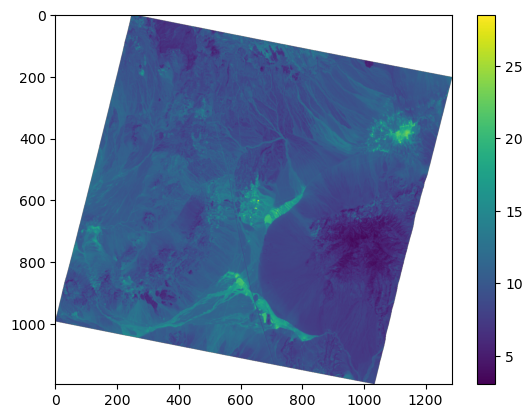

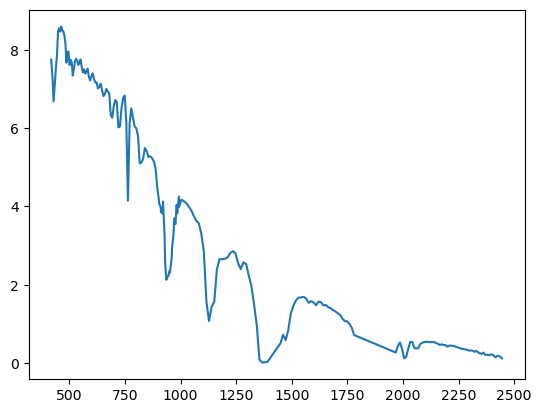

In [2]:
def get_coord_grid(ULxy, LRxy, out_resXY):
    X_vec = np.arange(ULxy[0], LRxy[0], out_resXY[0])
    Y_vec = np.arange(ULxy[1], LRxy[1], out_resXY[1])
    return np.meshgrid(X_vec, Y_vec)

fid = "ENMAP01-____L1C-DT0000025905_20230707T192008Z_001_V010303_20230922T131737Z"

enmap = GeoArray(f"{fid}-SPECTRAL_IMAGE.TIF")

xmin, xmax, ymin, ymax = enmap.box.boundsMap
xgsd, ygsd = (enmap.xgsd, enmap.ygsd)
x_grid, ygrid = get_coord_grid((xmin, ymax), (xmax, ymin), (xgsd, -ygsd))

print("EPSG of EnMAP image: " + str(enmap.epsg))

if enmap.epsg == 4326:
    lons = x_grid
    lats = ygrid
else:
    lons, lats = transform_coordArray(
        CRS(enmap.epsg).to_wkt(),
        CRS(4326).to_wkt(),
        x_grid, ygrid
    )

data = np.array(tifffile.imread(f"{fid}-SPECTRAL_IMAGE.TIF"))
data = np.swapaxes(data,0,2)
data = np.swapaxes(data,0,1)

path_xml = f"{fid}-METADATA.XML"
xml = etree.parse(path_xml).getroot()

bi = "specific/bandCharacterisation/bandID/"
wvl = np.array([float(ele.text) for ele in xml.findall(bi + "wavelengthCenterOfBand")])
fwhm = np.array([float(ele.text) for ele in xml.findall(bi + "FWHMOfBand")])
gains = np.array([float(ele.text) for ele in xml.findall(bi + "GainOfBand")])
offsets = np.array([float(ele.text) for ele in xml.findall(bi + "OffsetOfBand")])

print("Shape of EnMAP image: " + str(data.shape))

loc = np.zeros((data.shape[0], data.shape[1], 3))
obs = np.zeros((data.shape[0], data.shape[1], 11))

loc[:,:,0] = lons
loc[:,:,1] = lats
loc[:,:,2] = float(xml.findall("specific/meanGroundElevation")[0].text)/1000

obs[:,:,0] = float(xml.findall("base/altitudeCoverage")[0].text) - float(xml.findall("specific/meanGroundElevation")[0].text)
obs[:,:,1] = float(xml.findall("specific/sceneAzimuthAngle/center")[0].text)
obs[:,:,2] = float(xml.findall("specific/acrossOffNadirAngle/center")[0].text)
obs[:,:,3] = float(xml.findall("specific/sunAzimuthAngle/center")[0].text)
obs[:,:,4] = 90 - float(xml.findall("specific/sunElevationAngle/center")[0].text)

obs_copy = obs.copy()
obs[:,:,2][obs[:,:,2]<0] = obs_copy[:,:,2][obs[:,:,2]<0] * -1

metadata_rdn = {"wavelength": wvl, "fwhm": fwhm}
metadata_loc = {"band_names": ["Longitude (WGS-84)", "Latitude (WGS-84)", "Elevation (m)"]}
metadata_obs = {"band_names": ["Path length (m)", "To-sensor azimuth (0 to 360 degrees CW from N)", "To-sensor zenith (0 to 90 degrees from zenith)", "To-sun azimuth (0 to 360 degrees CW from N)",
                               "To-sun zenith (0 to 90 degrees from zenith)", "Solar phase", "Slope", "Aspect", "Cosine(i)", "UTC Time", "Earth-sun distance (AU)"]}

rdn = 100 * (data[:,:,:] * gains + offsets)

for row in range(rdn.shape[0]):
    for col in range(rdn.shape[1]):
        if data[row,col,0] == np.uint16(0):
            rdn[row,col,:] = np.nan

plt.figure()
plt.imshow(rdn[:,:,40])
plt.colorbar()

plt.figure()
plt.plot(wvl, rdn[100,450,:])

# Build image subsets for tutorial notebook

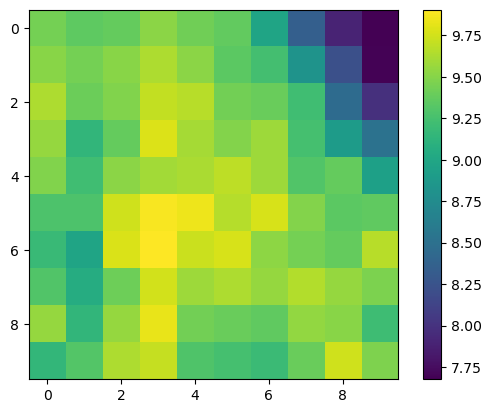

In [21]:
# create small subset

rdn_sub = rdn[400:410,400:410,:]
loc_sub = loc[400:410,400:410,:]
obs_sub = obs[400:410,400:410,:]

plt.imshow(rdn_sub[:,:,40])
plt.colorbar()

envi.save_image(f"small_example/{fid}_rdn_sub_small.hdr", rdn_sub, metadata=metadata_rdn, force=True)
envi.save_image(f"small_example/{fid}_loc_sub_small.hdr", loc_sub, metadata=metadata_loc, force=True)
envi.save_image(f"small_example/{fid}_obs_sub_small.hdr", obs_sub, metadata=metadata_obs, force=True)

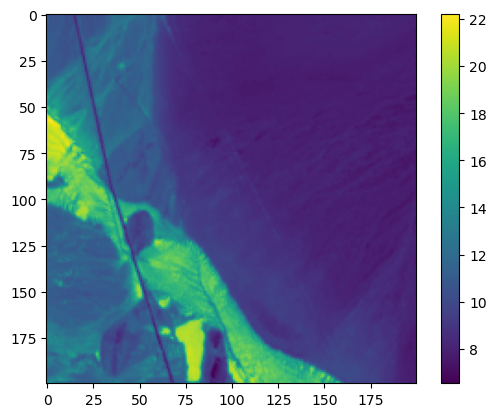

In [26]:
# create medium subset

rdn_sub = rdn[800:1000,600:800,:]
loc_sub = loc[800:1000,600:800,:]
obs_sub = obs[800:1000,600:800,:]

plt.imshow(rdn_sub[:,:,40])
plt.colorbar()

envi.save_image(f"medium_example/{fid}_rdn_sub_medium.hdr", rdn_sub, metadata=metadata_rdn, force=True)
envi.save_image(f"medium_example/{fid}_loc_sub_medium.hdr", loc_sub, metadata=metadata_loc, force=True)
envi.save_image(f"medium_example/{fid}_obs_sub_medium.hdr", obs_sub, metadata=metadata_obs, force=True)